In [1]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
import data_preprocess as dt
import pyteomics.auxiliary as aux
import ast
import tpp_preprocess as tpp

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#load number of spectra in each mgf file

mgfspectraN_datasets=pickle.load(open('./../../../junk/mgfspectraN_datasets.pickle', 'rb'))

#as tpp does not record spectra file (but merged, input), then add up corresponding merged files n of spectra

#PXD014258
mgfspectraN_datasets['PXD014258.v0.11.4']={f"{i}.mgf":np.sum([mgfspectraN_datasets['PXD014258.v0.11.4'][f"{i}{j}.RAW.mgf"] for j in range(1,6)]) 
     if "BT474" not in i 
    else np.sum([mgfspectraN_datasets['PXD014258.v0.11.4'][f"{i}_{j}.RAW.mgf"] for j in range(1,6)])
     for i in ["ESC-HF-Sample-BT474","ESC-HF-SampleHela","ESC-HF-Sample-MCF"]
}
del mgfspectraN_datasets['PXD003594.v0.11.4']
# trim mgf
tmp = mgfspectraN_datasets.copy()
for _, d in tmp.items():
    for key in list(d.keys()):
        mgfspectraN_datasets[_][key[:-4]] = mgfspectraN_datasets[_].pop(key)
# trim .v0.11.4
for _, d in tmp.items():
    mgfspectraN_datasets[_[:-8]] = mgfspectraN_datasets.pop(_)
#trim ESC-HF- in PXD014258
tmp = mgfspectraN_datasets.copy()
for _, d in tmp.items():
    if _ == 'PXD014258':
        for key in list(d.keys()):
            mgfspectraN_datasets[_][key[7:]] = mgfspectraN_datasets[_].pop(key)

In [3]:
# GLOBAL VARS
PIPELINE = 'ionbot_closed'
PIPELINE_LW = PIPELINE.lower()

In [4]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '.v0.11.4' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

### Load and filter

#### PSM - 1% Global FDR

In [5]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-closed-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            #data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            #data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

<Axes: title={'center': 'PSM count, 1% Global FDR'}, xlabel='dataset,search_database,spectrum_file'>

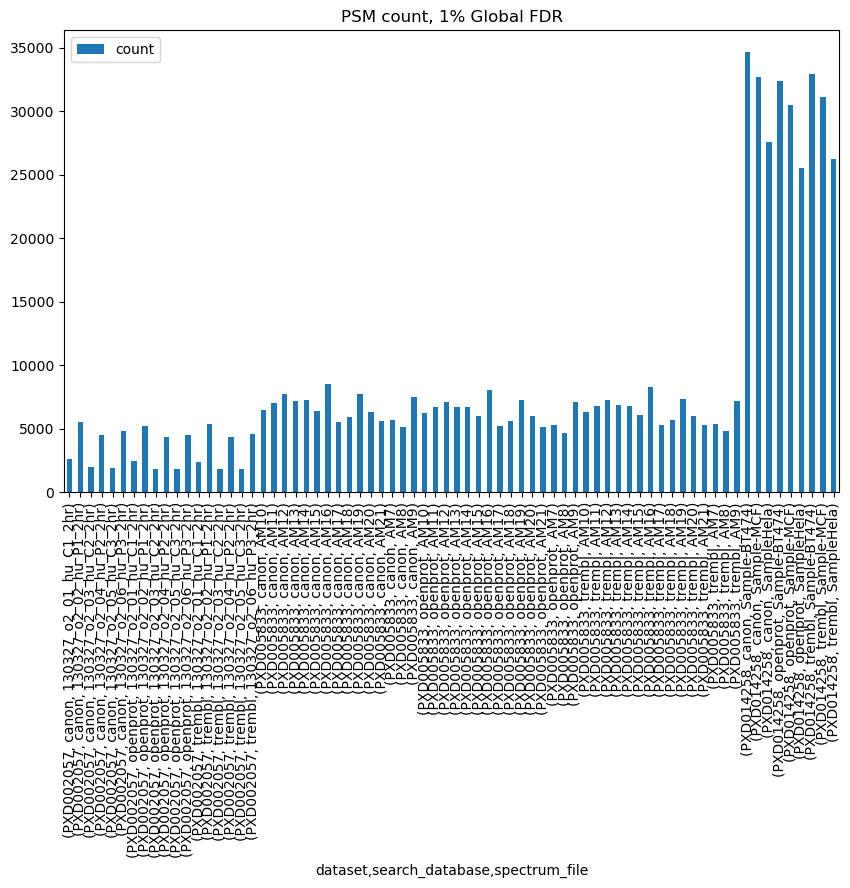

In [6]:
psm_filt[['dataset', 'search_database', 'spectrum_file']].value_counts().sort_index().to_frame().plot.bar(figsize=(10, 6), title='PSM count, 1% Global FDR')

#### Peptide - subset FDP-rank

In [7]:
pep_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt += [data]
pep_filt = pd.concat(pep_filt)
# NOTE: only target peptides are left
pep_filt = pep_filt[(pep_filt['subset_max_rank'] == True)&(pep_filt['isCanonical'] != 'Contam')]

# str to list
#pep_filt['protein'] = pep_filt['protein'].apply(lambda x: ast.literal_eval(x))
pep_filt['proteins'] = pep_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
pep_filt['isProteotypic'] = pep_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
pep_filt["peptide_class"]=pep_filt["proteins"].apply(tpp.classify_peptide_tpp)

In [8]:
# are some samples missing in peptide level due to filter? --yes

a = set(tuple(map(tuple, psm_filt[['dataset', 'search_database', 'spectrum_file']].drop_duplicates().values)))
b = set(tuple(map(tuple, pep_filt[['dataset', 'search_database', 'spectrum_file']].drop_duplicates().values)))
len(a) == len(a & b)

True

<Axes: title={'center': 'Peptide count, subset FDP-rank'}, xlabel='dataset,search_database,spectrum_file'>

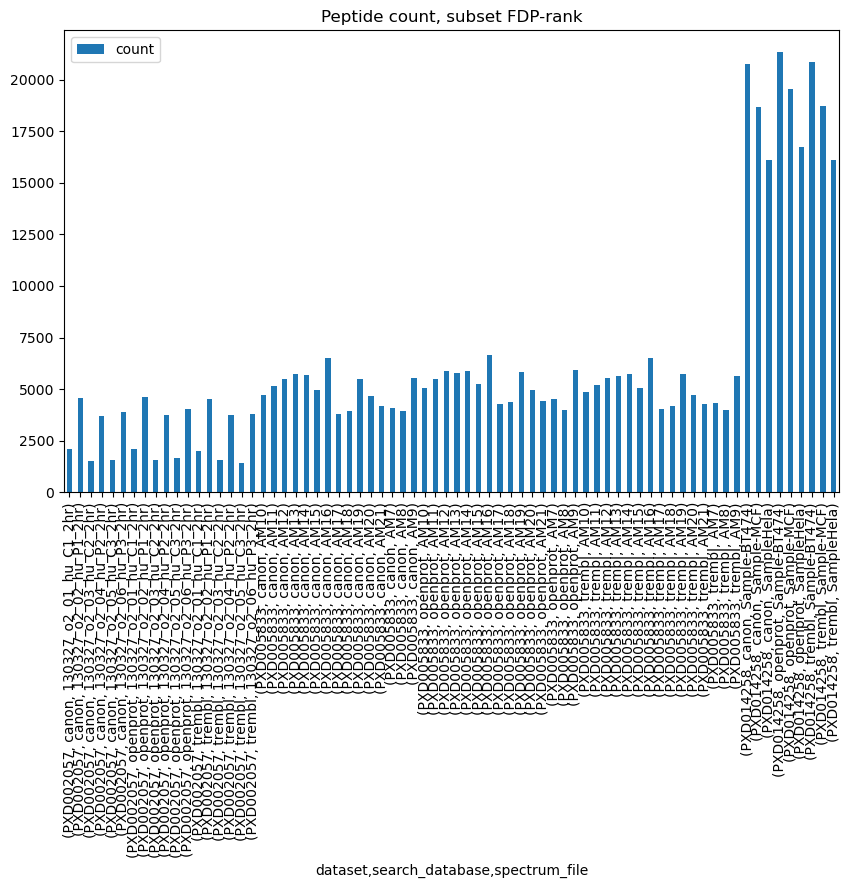

In [9]:
pep_filt[['dataset', 'search_database', 'spectrum_file']].value_counts().sort_index().to_frame().plot.bar(figsize=(10, 6), title='Peptide count, subset FDP-rank')

#### Protein level - add Non-canon w 1+ proteotipic peptide

In [10]:
def classify_leadprot(x):
    x=x.replace("decoy_","")
    if 'CONTAMINANT' in x.upper():
        return 'Contam'
    elif x.startswith('II_') or x.startswith('IP_'):
        return 'NonCanon'
        # Ensembl is canonical
    else:
        return 'Canon'
def is_peptide_canonical(x):
    '''x is the list of protein classes'''
    if np.array([_=='Contam' for _ in x]).any():
        return 'Contam'
    if np.array([_=='Canon' for _ in x]).any():
        return 'Canonical'
    return 'NonCanonical'

In [11]:
prot_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'sample_protein_groups_Occam.csv': #-closed-db
            data = pd.read_csv(os.path.join(parent, file))
            prot_filt += [data]
prot_filt = pd.concat(prot_filt)
prot_filt["protein_classes"] = prot_filt.proteins.apply(lambda x: np.unique([classify_leadprot(_) for _ in x.split(',')]))
prot_filt["isCanonical"] = prot_filt.protein_classes.apply(is_peptide_canonical)

In [12]:
print('From protein inference',len(prot_filt))
# NOTE: it has no decoys and contaminants
prot_filt = prot_filt[(prot_filt['isCanonical'] == 'Canonical')] #remove non-canonical proteins 9including those with only shared peptides)
print('Canonical',len(prot_filt))

# Get noncanonical proteins with at least one proteotypic peptide
prot_noncanon = pep_filt[
    (pep_filt['search_database'] == 'openprot')&
    (pep_filt['isCanonical'] == 'NonCanonical')&
    (pep_filt['isProteotypic'] == True)
].sort_values('psm_score').drop_duplicates(['spectrum_file','database_peptide'],keep='first')
# select relevant columns
prot_noncanon = prot_noncanon[['proteins','database','psm_score','spectrum_file','dataset','search_database','is.decoy','q.value','protein_classes','isCanonical']]
#prot_noncanon['isModified'] = pd.NA
prot_noncanon['proteins'] = prot_noncanon['proteins'].apply(lambda x: ','.join(x))
prot_noncanon.columns = prot_filt.columns

# Uppend noncanonical to proteins set
prot_filt = pd.concat([prot_filt, prot_noncanon])
print('Canonical + Non-canonical',len(prot_filt))

# indicate groups and proteins with proteotypic peptides
prot_filt['level'] = prot_filt.proteins.apply(lambda x: "Group" if "," in x else "Singleton")

#correct dataset
prot_filt['PXD'] = prot_filt['PXD'].str.replace('-closed','')

From protein inference 92509
Canonical 92332
Canonical + Non-canonical 92679


### Identification rate by search

In [13]:
id_rates = []
for (dataset, spectrum_file, search_database), df in psm_filt.groupby(['dataset', 'spectrum_file','search_database']):
    n_spec = mgfspectraN_datasets[dataset][spectrum_file]
    id_rate = len(df[df['database'] == 'T'])/n_spec
    id_rates += [[PIPELINE,dataset, spectrum_file, search_database, id_rate]]
id_rates = pd.DataFrame(id_rates, columns = ["pipeline","dataset","sample","database","value"])   
id_rates.to_pickle(f"{results_dir}/{PIPELINE_LW}_idrate_datasets_df.pkl")

In [14]:
#sns.stripplot(data=id_rates, x='database', y='value', hue='dataset')

### Identification rate by peptide class

In [15]:
id_rates_pepcl = []
for (dataset, spectrum_file, peptide_class), df in psm_filt[psm_filt['search_database'] == 'openprot'].groupby(['dataset', 'spectrum_file','peptide_class']):
    n_spec = mgfspectraN_datasets[dataset][spectrum_file]
    id_rate = len(df[df['database'] == 'T'])/n_spec
    id_rates_pepcl += [[PIPELINE,dataset, spectrum_file, peptide_class, id_rate]]
id_rates_pepcl = pd.DataFrame(id_rates_pepcl, columns = ["pipeline","dataset","sample","peptide_class","value"])  
id_rates_pepcl.to_pickle(f"{results_dir}/{PIPELINE_LW}_PEPCL_idrate_datasets_df.pkl")

In [16]:
#sns.stripplot(data=id_rates_pepcl, x='peptide_class', y='value', hue='dataset')

### Peptides' reproducability across datasets

In [17]:
# count of peptides in 1,2, 2+ samp per dataset and all datasets and per peptide_class

pep_repr = []
for (dataset, search_database, peptide_class), df in pep_filt.groupby(['dataset', 'search_database','peptide_class']):
    n_pep_per_samp = Counter(df['database_peptide'].value_counts())
    more_2 = sum(n_pep for n_samp, n_pep in n_pep_per_samp.items() if n_samp>2)
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '1', n_pep_per_samp[1] ]]
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '2', n_pep_per_samp[2] ]]
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '2+', more_2 ]]
# across all datasets
for (search_database, peptide_class), df in pep_filt.groupby(['search_database','peptide_class']):
    n_pep_per_samp = Counter(df['database_peptide'].value_counts())
    more_2 = sum(n_pep for n_samp, n_pep in n_pep_per_samp.items() if n_samp>2)
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '1', n_pep_per_samp[1] ]]
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '2', n_pep_per_samp[2] ]]
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '2+', more_2 ]]
pep_repr = pd.DataFrame(pep_repr, columns = ["pipeline","dataset","search_database","peptide_class","n_samp","value"]) 
pep_repr.to_pickle(f"{results_dir}/{PIPELINE_LW}_peptides_across_samples_PEP_df.pkl")

In [18]:
#sns.stripplot(data=pep_repr, x='peptide_class', y='value', hue='dataset')

### Number of PSMs per peptide class

In [19]:
psm_pepcl = []
bins = [[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
for (peptide, peptide_class), df in psm_filt[(psm_filt['search_database'] == 'openprot')&(psm_filt['database'] == 'T')].groupby(['database_peptide', 'peptide_class']):
    n_psm = len(df)
    b_i = [i for i,b in bins_i if n_psm in b][0]
    psm_pepcl += [[PIPELINE, peptide, peptide_class, n_psm, b_i]]
psm_pepcl = pd.DataFrame(psm_pepcl, columns = ["pipeline","peptide","peptide_class","psm_num","bin"]) 
psm_pepcl.to_pickle(f"{results_dir}/{PIPELINE_LW}_pepcl_psm_frq.pkl")

In [20]:
#sns.kdeplot(data=psm_pepcl,x='psm_num', hue='peptide_class')

In [21]:
#sns.barplot(data=psm_pepcl,x='bin',y='psm_num', hue='peptide_class')

### Number of proteins by search database

In [22]:
prot_filt['PXD'].unique()

array(['PXD005833', 'PXD014258', 'PXD002057'], dtype=object)

In [23]:
prot_db = []
for database, df in prot_filt.groupby('searchDB'):
    group_sing=df[df.level=="Singleton"]
    group_uplim=df[df.level=="Group"]
    singletons=set(group_sing.proteins.tolist())
    uplim=set([p for g in group_uplim.proteins.tolist() for p in g.split(",")])
    prot_db += [[PIPELINE, database, "singletons", len(singletons)]]
    prot_db += [[PIPELINE, database, "indistinguishable proteins",len(uplim-singletons)]]
prot_db = pd.DataFrame(prot_db, columns = ["pipeline","database","group","value"]) 
prot_db.to_pickle(f"{results_dir}/{PIPELINE_LW}_bysearch_proteins.pkl")

In [24]:
#sns.barplot(data=prot_db, y='value',x='database', hue='group')

### Proteins reproducability

In [25]:
def get_prot_repr(df,pipeline,dataset, search_database):
    prot_repr = []
    sing = df[df['level']=='Singleton']
    n_sing_per_samp = Counter(sing['proteins'].value_counts())
    more_2_sing = sum(n_pep for n_samp, n_pep in n_sing_per_samp.items() if n_samp>2)
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '1', n_sing_per_samp[1] ]]
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '2', n_sing_per_samp[2] ]]
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '2+', more_2_sing ]]
    group = df[df['level']=='Group']
    group['proteins'] = group['proteins'].str.split(',')
    group = group.explode('proteins')
    uplim = group[~group['proteins'].isin(sing['proteins'].tolist())]
    uplim = uplim.drop_duplicates(['proteins','experiment']) # proteins from groups appear more than once
    n_uplim_per_samp = Counter(uplim['proteins'].value_counts())
    more_2_uplim = sum(n_pep for n_samp, n_pep in n_uplim_per_samp.items() if n_samp>2)
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '1', n_uplim_per_samp[1] ]]
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '2', n_uplim_per_samp[2] ]]
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '2+', more_2_uplim ]]
    return prot_repr

In [26]:
# count of proteins in 1,2, 2+ samp per dataset and all datasets and per level

prot_repr = []
for (dataset, search_database), df in prot_filt.groupby(['PXD', 'searchDB',]):
    prot_repr += get_prot_repr(df, PIPELINE, dataset, search_database)
    
# across all datasets
for search_database, df in prot_filt.groupby('searchDB'):
    prot_repr += get_prot_repr(df, PIPELINE, 'all', search_database)
prot_repr = pd.DataFrame(prot_repr, columns = ["pipeline","dataset","search_database","level","n_samp","value"]) 
prot_repr.to_pickle(f"{results_dir}/{PIPELINE_LW}_prot_reproduce_PXD_{PIPELINE_LW}_protcl_counts.pkl")

/tmp/ipykernel_1116677/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['proteins'] = group['proteins'].str.split(',')
/tmp/ipykernel_1116677/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['proteins'] = group['proteins'].str.split(',')
/tmp/ipykernel_1116677/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [27]:
#for level, df in prot_repr.groupby('level'):
#    sns.barplot(data=df[df['dataset']!='all'],x='search_database',y='value',hue='n_samp')
#    plt.title(level)
#    plt.show()

### Number of proteins per protein class

In [28]:
prot_cls = []
for (search_database,isCanonical), df in prot_filt.groupby(['searchDB', 'isCanonical']):
    group_sing=df[df.level=="Singleton"]
    group_uplim=df[df.level=="Group"]
    singletons=set(group_sing.proteins.tolist())
    uplim=set([p for g in group_uplim.proteins.tolist() for p in g.split(",")])
    prot_cls += [[PIPELINE, search_database, isCanonical,"singletons", len(singletons)]]
    prot_cls += [[PIPELINE, search_database, isCanonical,"indistinguishable proteins", len(uplim-singletons)]]
prot_cls = pd.DataFrame(prot_cls,columns = ["pipeline","search","protein_class","group","value"])
prot_cls.to_pickle(f"{results_dir}/{PIPELINE_LW}_byprotclass_proteins.pkl")

In [29]:
#for level, df in prot_cls.groupby('group'):
#    sns.barplot(data=df, x='search',y='value',hue='protein_class')
#    plt.title(level)
#    plt.show()

### Number of peptides & PSMs per protein per protein class

In [30]:
# Deduplicate proteins, by sample
prot_filt_op = prot_filt[prot_filt['searchDB'] == 'openprot']
prot_filt_op['proteins'] = prot_filt_op['proteins'].str.split(',')
prot_filt_op = prot_filt_op.explode('proteins')
prot_filt_op = prot_filt_op.sort_values('level') # G->S
prot_filt_op = prot_filt_op.drop_duplicates('proteins',keep='last') #keep singleton mark if also part of group
# Deduplicate peptides by sample
pep_filt_op = pep_filt[pep_filt['search_database'] == 'openprot']
pep_filt_op = pep_filt_op.drop_duplicates('database_peptide',keep='first')
pep_filt_op = pep_filt_op.explode('proteins')
pep_filt_op = pep_filt_op[pep_filt_op['proteins'].isin(prot_filt_op['proteins'].tolist())] #select only peptides present on protein level
# PSM
psm_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
psm_filt_op = psm_filt_op.explode('proteins')
psm_filt_op = psm_filt_op[psm_filt_op['proteins'].isin(prot_filt_op['proteins'].tolist())] #select only PSM present on protein level

#NOTE each df has duplicated rows due to protein groups expansion

/tmp/ipykernel_1116677/1825217463.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot_filt_op['proteins'] = prot_filt_op['proteins'].str.split(',')


In [31]:
len(prot_filt_op), len(pep_filt_op), len(psm_filt_op)

(34012, 262663, 1463366)

In [32]:
#merge peptide class
pep_per_prot = []
for (isCanonical, level), df in prot_filt_op.groupby(['isCanonical', 'level']):
   # Precompute peptide counts per protein once
    counts = pep_filt_op['proteins'].value_counts()
    result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
    result.columns = ['proteins','value']
    result['level'] = level
    result['protein_class'] = isCanonical
    pep_per_prot += [result]
pep_per_prot = pd.concat(pep_per_prot)
pep_per_prot.to_pickle(f"{results_dir}/{PIPELINE_LW}_pep_per_prot.pkl")

In [33]:
#sns.barplot(data=pep_per_prot, x='protein_class', y='value', hue='level')

In [34]:
#merge peptide class
psm_per_prot = []
for (isCanonical, level), df in prot_filt_op.groupby(['isCanonical', 'level']):
   # Precompute peptide counts per protein once
    counts = psm_filt_op['proteins'].value_counts()
    result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
    result.columns = ['proteins','value']
    result['level'] = level
    result['protein_class'] = isCanonical
    psm_per_prot += [result]
psm_per_prot = pd.concat(psm_per_prot)
psm_per_prot.to_pickle(f"{results_dir}/{PIPELINE_LW}_psm_per_prot.pkl")

In [35]:
#sns.barplot(data=psm_per_prot, x='protein_class', y='value', hue='level')

### Proteotypic peptides coverage

In [36]:
all_peptide_sequences=pickle.load(open('./../../../junk/all_peptide_sequences_OP_7302.pkl', 'rb'))
is_unique=pickle.load(open('./../../../junk/is_unique_OP_7302.pkl', 'rb'))

In [37]:
# Repeat protein for each protein in group

proteins_op = prot_filt_op.copy(deep=True)

In [38]:
#Load OpenProt database

OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [39]:
prophet_filt_op=pep_filt_op.copy(deep=True)
#Drop PEPTIDE to same peptide and protein
prophet_filt_op.drop_duplicates(["database_peptide","proteins"],inplace=True,keep="first")
prophet_filt_op.reset_index(drop=True,inplace=True)

In [40]:
#Leave only proteotypic peptides
prophet_filt_op=prophet_filt_op[prophet_filt_op.isProteotypic==True]

In [41]:
#get the peptides' positions in proteins

count_var=0
prophet_filt_op["peptide_position"]='nan'
for i,row in prophet_filt_op.iterrows():
    peptide=row["database_peptide"]; prot=row["proteins"]
    #prot_seq=str(OPfasta[f"op|{prot}|TX=9606"].seq)
    prot_seq=str(OPfasta[prot].seq)
    pos=hpp.get_pep_positions(prot_seq,peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        peptide = peptide.replace('L','I')
        prot_seq=str(OPfasta[prot].seq)
        pos=hpp.get_pep_positions(prot_seq,peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
            print(peptide,prot,prot_seq)
    prophet_filt_op.at[i,"peptide_position"]=[[pos[0]]]#pd.Series([pos[0]]).values[0]
#are their peptides with SAAVs introduced 
print(count_var)
#drop peptides with SAAVs introduced by Comet
prophet_filt_op=prophet_filt_op[~prophet_filt_op.peptide_position.isna()]

0


In [42]:
#Select proteotypic peptides from in silico digested database

all_peptide_sequences_identunique={}
for prot in set(prophet_filt_op['proteins'].tolist()):
    try:
        peps=all_peptide_sequences[f"op|{prot}|TX=9606"]
        peps_unique=[is_unique[p]  for p in peps]
        peps_unique=np.array(peps)[peps_unique]
        all_peptide_sequences_identunique[prot]=peps_unique
    except KeyError:  #skip contominants
        continue

In [43]:
#Get positions of in-silico proteotypic peptides in proteins

all_peptide_sequences_identunique_pos={}
for prot,uniquepeps in all_peptide_sequences_identunique.items():
    group=pd.DataFrame({"database_peptide":list(uniquepeps),"peptide_position":[np.nan]*len(uniquepeps)})
    #prot_seq=str(OPfasta[f"op|{prot}|TX=9606"].seq)
    prot_seq=str(OPfasta[prot].seq)
    #in this fasta all L are replaced to I, so correct for this
    uniquepeps=[pep.replace("L","I") for pep in uniquepeps]
    uniquepeps_pos=[]
    for pep in uniquepeps:
        pos=hpp.get_pep_positions(prot_seq,pep)
        if len(pos)>1: pos=[pos[0]]
        uniquepeps_pos=uniquepeps_pos+pos
    group["peptide_position"]=uniquepeps_pos
    all_peptide_sequences_identunique_pos[prot]=group

In [44]:
#Add positions data of peptides, identified 

all_peptide_sequences_identunique_pos_wident={}
for prot,uniquepeps_df in all_peptide_sequences_identunique_pos.items():
    ident_df=prophet_filt_op.groupby("proteins").get_group(prot)
    all_peptide_sequences_identunique_pos_wident[prot]=uniquepeps_df.merge(ident_df[["database_peptide","peptide_position"]],how="outer",on="database_peptide")

In [45]:
def flatten_tuples(obj):
    """Recursively flatten nested lists of tuples."""
    if isinstance(obj, list):
        result = []
        for item in obj:
            result.extend(flatten_tuples(item))
        return result
    elif isinstance(obj, tuple):
        return [obj]
    else:
        return []

In [46]:
#Coverage

unique_peptide_aa_coverege={}
dict_deepcopy=copy.deepcopy(all_peptide_sequences_identunique_pos_wident)
for prot_i,uniquepeps_df in dict_deepcopy.items():
    #if peptide not known by in silico, add it to a set of theoretical proteotypic peptides
    uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_x"]= uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_y"]
    #get total extant of overlaping proteotypic peptides
    l = flatten_tuples(uniquepeps_df.peptide_position_x.tolist())
    #print(l)
    _, theory=hpp.find_max_length_in_overlap_groups(l)
    l = flatten_tuples(uniquepeps_df[~uniquepeps_df.peptide_position_y.isna()].peptide_position_y.tolist())
    #print(l)
    _,practice=hpp.find_max_length_in_overlap_groups(l)#drop nan
    #percent of total extent, covered by identified peptides
    theory_cov=np.sum([abs(rang[0]-rang[1]) for rang in theory])
    practice_cov=np.sum([abs(rang[0]-rang[1]) for rang in practice])
    ratio=practice_cov/theory_cov
    if ratio==np.inf: ratio=1
    unique_peptide_aa_coverege[prot_i]=[ratio] #normalise by num of theoretical peptides

In [47]:
#combine data
unique_peptide_aa_coverege_df=pd.DataFrame(unique_peptide_aa_coverege).T
unique_peptide_aa_coverege_df.columns=["value"]
unique_peptide_aa_coverege_df.sort_index(inplace=True)
a=prophet_filt_op[prophet_filt_op.proteins.isin(unique_peptide_aa_coverege_df.index.tolist())]
a.drop_duplicates("proteins",inplace=True,keep="first")
a.sort_values(["proteins"],inplace=True)
unique_peptide_aa_coverege_df["peptide_class"]=a["peptide_class"].tolist()
unique_peptide_aa_coverege_df["pipeline"]=PIPELINE_LW
unique_peptide_aa_coverege_df.to_pickle(f"{results_dir}/{PIPELINE_LW}_unique_peptide_aa_coverege_df.pkl")